# What is the most optimal skill to learn for Data Analysts?

#### Methodology

1. Group skills to determine median salary and likelihood of being in posting
2. Visualize median salary vs percent skill demand
3. Determine if certain technologies are more prevalent

In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


## 1. Group skills to determine median salary and likelihood of being in posting

In [4]:
# Get Data Analysts jobs in the US
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
36,Data Analyst,Data Analyst,"Des Moines, IA",via Trabajo.org,Full-time,False,"Illinois, United States",2023-11-06 13:01:22,False,True,United States,None,NaN,NaN,Assuredpartners,None,None
68,Data Analyst,Sr. Research Data Analyst,"Baltimore, MD",via ZipRecruiter,Full-time,False,"New York, United States",2023-03-24 13:01:00,False,False,United States,None,NaN,NaN,Johns Hopkins Medicine,"[r, zoom]","{'programming': ['r'], 'sync': ['zoom']}"
73,Data Analyst,Entry level / Systems Data Analyst (Remote),Anywhere,via LinkedIn,Contractor,True,"Illinois, United States",2023-06-16 13:18:22,True,True,United States,None,NaN,NaN,Soft Magic,"[word, excel, powerpoint, outlook]","{'analyst_tools': ['word', 'excel', 'powerpoin..."
79,Data Analyst,Data Analyst/Report Writer,"Austin, TX",via Jobs Trabajo.org,Full-time,False,"Texas, United States",2023-08-07 13:18:27,True,False,United States,None,NaN,NaN,Nesco Resource,"[sas, sas, word, excel]","{'analyst_tools': ['sas', 'word', 'excel'], 'p..."
93,Data Analyst,IT Finance / TBM Data Analyst - Remote | WFH,Anywhere,via LinkedIn,Full-time,True,"New York, United States",2023-06-10 13:00:05,False,False,United States,None,NaN,NaN,Get It Recruit - Information Technology,"[oracle, azure, power bi, excel, word, powerpo...","{'analyst_tools': ['power bi', 'excel', 'word'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785603,Data Analyst,Junior Data Analyst,"Santa Monica, CA",via Trabajo.org,Full-time,False,"California, United States",2023-09-12 06:00:50,False,False,United States,None,NaN,NaN,"Ramax Search, Inc.","[sql, vba, python, excel, flow]","{'analyst_tools': ['excel'], 'other': ['flow']..."
785626,Data Analyst,Data Acquisition Associate,"Tarrytown, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-29 06:01:29,False,False,United States,None,NaN,NaN,Planet Group,[microsoft teams],{'sync': ['microsoft teams']}
785685,Data Analyst,Data Analyst,"Indianapolis, IN",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-16 06:01:27,True,False,United States,None,NaN,NaN,"Aara Technologies, Inc","[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,None,NaN,NaN,Axelon Services Corporation,None,None


In [6]:
# Drop NA values from salary year average
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

# Explode out the job skills column so each skill is on a seperate row
df_DA_US_exploded = df_DA_US.explode('job_skills')

# Inspect the salary year average and job skills to ensure we are on the right track
df_DA_US_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [ ]:
# Group the job skills by median salary and job count of those skills
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

# Rename the count and median columns to be more descriptive
df_DA_skills = df_DA_skills.rename(columns={'count':'skill_count', 'median':'median_salary'})
df_DA_skills

,skill_count,median_salary
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0
...,...,...
couchbase,1,160515.0
chainer,1,100000.0
chef,1,85000.0


In [14]:
# Get the total job counts to use to calculate percentages of job skill counts
DA_job_count = len(df_DA_US)

# Add a new column to the U.S. Data Analyst skills data frame with the calculated percentage of those skills for all job postings in the U.S.
df_DA_skills['skill_percentage'] = df_DA_skills['skill_count'] / DA_job_count * 100

# Exclude any skill with skill percentage below 5%
skill_min_percent = 5

# Filter the data frame to excude skills that are below the min percentage desired
df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percentage'] > skill_min_percent]

df_DA_skills_high_demand

,skill_count,median_salary,skill_percentage
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


## 2. Visualize median salary vs percent skill demand

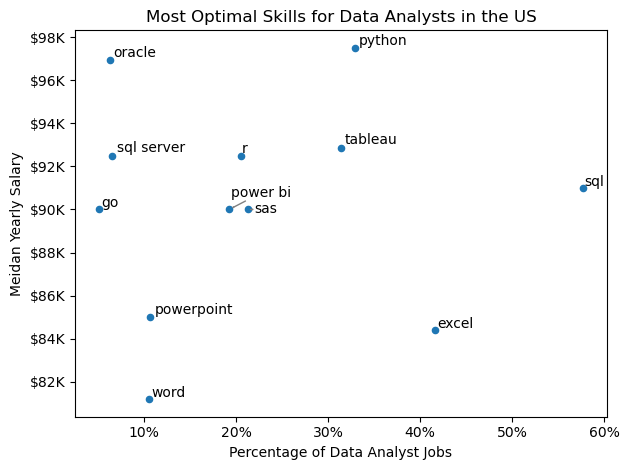

In [19]:
# Adjust the Y axis labels
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

df_DA_skills_high_demand.plot(kind='scatter', x='skill_percentage', y='median_salary')

texts = []

for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(plt.text(df_DA_skills_high_demand['skill_percentage'].iloc[i], df_DA_skills_high_demand['median_salary'].iloc[i], txt))
    

adjust_text(texts,  arrowprops=dict(arrowstyle='->', color='gray', lw=1))

# Need to get the access object to apply the label adjustments to. Must be called after the plotting call
ax = plt.gca() # gca = Get Current Axis

# Format the y axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

# Format the x axis
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.xlabel('Percentage of Data Analyst Jobs')
plt.ylabel('Meidan Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.tight_layout()
plt.show()

## 3. Determine if certain technologies are more prevalent

In [20]:
# Inspect job skill types
df['job_type_skills'].head(10)

0                                                 None
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: object

The below code removes duplicate entries and any rows with missing values. Then, it combines all dictionary entries into a single dictionary, summing values for keys that repeat across entries. To ensure each key's values are unique, it converts the values to a set and then back to a list. The final result is a dictionary where each key represents a skill and each value is a list of unique attributes associated with that skill.

In [ ]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['spss',
  'alteryx',
  'excel',
  'power bi',
  'dax',
  'ssis',
  'msaccess',
  'sharepoint',
  'sas',
  'esquisse',
  'looker',
  'visio',
  'spreadsheet',
  'tableau',
  'powerpoint',
  'nuix',
  'qlik',
  'word',
  'microstrategy',
  'cognos',
  'outlook',
  'ssrs',
  'ms access',
  'datarobot',
  'splunk',
  'sap',
  'powerbi',
  'sheets'],
 'programming': ['c++',
  'c#',
  'swift',
  'julia',
  'vb.net',
  'typescript',
  'kotlin',
  'cobol',
  'powershell',
  't-sql',
  'visualbasic',
  'ocaml',
  'ruby',
  'clojure',
  'sql',
  'css',
  'lua',
  'matlab',
  'shell',
  'dart',
  'apl',
  'sas',
  'lisp',
  'java',
  'html',
  'mongo',
  'haskell',
  'pascal',
  'assembly',
  'r',
  'c',
  'f#',
  'delphi',
  'nosql',
  'php',
  'solidity',
  'perl',
  'elixir',
  'scala',
  'fortran',
  'groovy',
  'sass',
  'visual basic',
  'crystal',
  'vba',
  'objective-c',
  'go',
  'bash',
  'javascript',
  'golang',
  'mongodb',
  'erlang',
  'no-sql',
  'rust',
  'pyt

In [23]:
# Convert dictionary to data frame
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

# Explode out the skills column into seperate rows
df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,spss
0,analyst_tools,alteryx
0,analyst_tools,excel
0,analyst_tools,power bi
0,analyst_tools,dax
...,...,...
9,sync,unify
9,sync,rocketchat
9,sync,wire
9,sync,zoom


In [ ]:
# Join the technology type back to the skills high demand via job skills
df_plot = df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

,skill_count,median_salary,skill_percentage,technology,skills
0,2508,91000.00,57.655172,programming,sql
1,1808,84392.00,41.563218,analyst_tools,excel
2,1431,97500.00,32.896552,programming,python
3,1364,92875.00,31.356322,analyst_tools,tableau
4,926,90000.00,21.287356,analyst_tools,sas
5,926,90000.00,21.287356,programming,sas
6,893,92500.00,20.528736,programming,r
7,838,90000.00,19.264368,analyst_tools,power bi
8,462,85000.00,10.620690,analyst_tools,powerpoint
9,461,81194.75,10.597701,analyst_tools,word


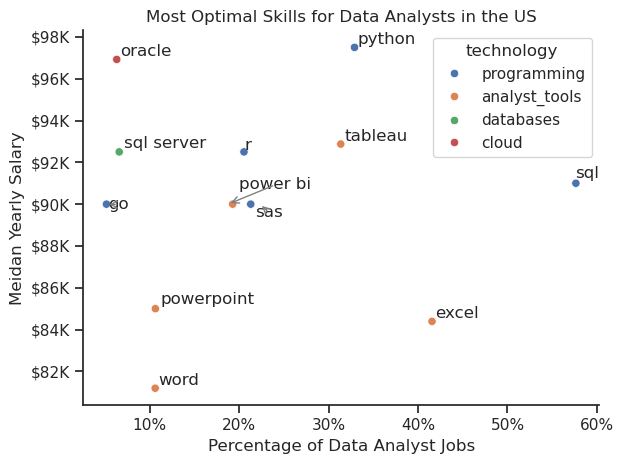

In [70]:
# Adjust the Y axis labels
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter


sns.set_theme(style='ticks')
#df_plot.plot(kind='scatter', x='skill_percentage', y='median_salary')
sns.scatterplot(
    data=df_plot,
    x='skill_percentage',
    y='median_salary',
    hue='technology'
)

sns.despine()

texts = []

df_labels = df_plot.drop_duplicates(
    subset=['skills', 'skill_percentage', 'median_salary']
)

for i, row in df_labels.iterrows():
    x_offset = 0
    y_offset = 0

    if row['skills'] == 'power bi':
        x_offset = -0.5
        y_offset = 0.5

    if row['skills'] == 'sas':
        x_offset = 1
        y_offset = -0.5

    texts.append(
        plt.text(
            row['skill_percentage'] + x_offset, 
            row['median_salary'] + y_offset, 
            row['skills']
            )
        )
    

adjust_text(
    texts,  
    expand_points=(1.5, 1.5),
    expand_text=(1.5, 1.5),
    force_text=1.5,
    force_points=1.5,
    arrowprops=dict(arrowstyle='->', color='gray', lw=1)
    )

# Need to get the access object to apply the label adjustments to. Must be called after the plotting call
ax = plt.gca() # gca = Get Current Axis

# Format the y axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

# Format the x axis
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.xlabel('Percentage of Data Analyst Jobs')
plt.ylabel('Meidan Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the US')
plt.tight_layout()
plt.show()
